In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes = True)  # --> for getting nice backgroud to the graphs
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [103]:
Data = pd.read_csv('/content/Netflix Userbase.csv')

In [104]:
Data.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


In [105]:
Data.shape

(2500, 10)

In [106]:
Data.columns

Index(['User ID', 'Subscription Type', 'Monthly Revenue', 'Join Date',
       'Last Payment Date', 'Country', 'Age', 'Gender', 'Device',
       'Plan Duration'],
      dtype='object')

In [107]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   User ID            2500 non-null   int64 
 1   Subscription Type  2500 non-null   object
 2   Monthly Revenue    2500 non-null   int64 
 3   Join Date          2500 non-null   object
 4   Last Payment Date  2500 non-null   object
 5   Country            2500 non-null   object
 6   Age                2500 non-null   int64 
 7   Gender             2500 non-null   object
 8   Device             2500 non-null   object
 9   Plan Duration      2500 non-null   object
dtypes: int64(3), object(7)
memory usage: 195.4+ KB


In [108]:
Data.isnull().sum()

,0
User ID,0
Subscription Type,0
Monthly Revenue,0
Join Date,0
Last Payment Date,0
Country,0
Age,0
Gender,0
Device,0
Plan Duration,0


In [109]:
Data.duplicated().sum()

np.int64(0)

In [110]:
Data['Join Date'] = pd.to_datetime(Data['Join Date'])
Data['Last Payment Date'] = pd.to_datetime(Data['Last Payment Date'])

In [111]:
from scipy import stats

In [112]:
print("Mean Age:", Data['Age'].mean())
print("Median Age:", Data['Age'].median())
print("Mode Age:", Data['Age'].mode()[0])

print()

print("Mean Revenue:", Data['Monthly Revenue'].mean())
print("Median Revenue:", Data['Monthly Revenue'].median())
print("Mode Revenue:", Data['Monthly Revenue'].mode()[0])

Mean Age: 38.7956
Median Age: 39.0
Mode Age: 30

Mean Revenue: 12.5084
Median Revenue: 12.0
Mode Revenue: 12


In [113]:
print("Age Standard Deviation:", Data['Age'].std())
print("Age Variance:", Data['Age'].var())

print()

print("Revenue Standard Deviation:", Data['Monthly Revenue'].std())
print("Revenue Variance:", Data['Monthly Revenue'].var())

Age Standard Deviation: 7.171777631644703
Age Variance: 51.434394397759306

Revenue Standard Deviation: 1.6868513944775492
Revenue Variance: 2.8454676270508523


In [114]:
# Current date
current_date = pd.to_datetime('2023-07-04')

# Create active status
Data['active_status'] = (
    (current_date - Data['Last Payment Date']).dt.days <= 30
)

# Convert True/False to Yes/No
Data['active_status'] = Data['active_status'].map({
    True: 'Yes',
    False: 'No'
})

Data.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,active_status
0,1,Basic,10,2022-01-15,2023-10-06,United States,28,Male,Smartphone,1 Month,Yes
1,2,Premium,15,2021-05-09,2023-06-22,Canada,35,Female,Tablet,1 Month,Yes
2,3,Standard,12,2023-02-28,2023-06-27,United Kingdom,42,Male,Smart TV,1 Month,Yes
3,4,Standard,12,2022-10-07,2023-06-26,Australia,51,Female,Laptop,1 Month,Yes
4,5,Basic,10,2023-01-05,2023-06-28,Germany,33,Male,Smartphone,1 Month,Yes


In [115]:
# Churn rate percentage
churn_rate = (
    Data['active_status'].value_counts(normalize=True) * 100
)

print(churn_rate)

active_status
Yes    73.48
No     26.52
Name: proportion, dtype: float64


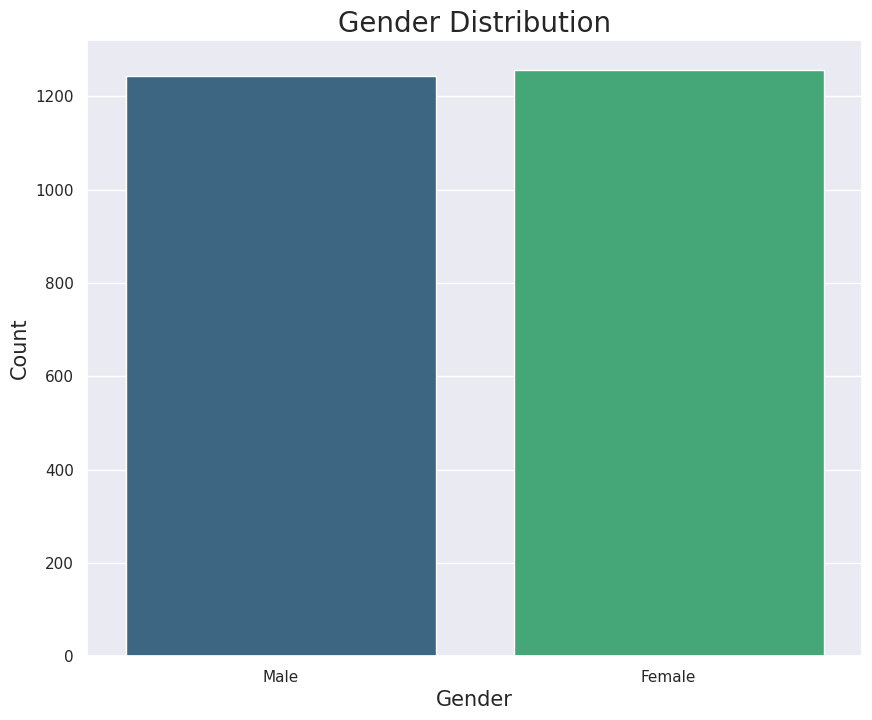

In [116]:
plt.figure(figsize = (10,8))
sns.countplot(x='Gender', data = Data, palette='viridis')
plt.title('Gender Distribution',fontsize = 20)
plt.xlabel('Gender',fontsize = 15)
plt.ylabel('Count',fontsize = 15)
plt.show()

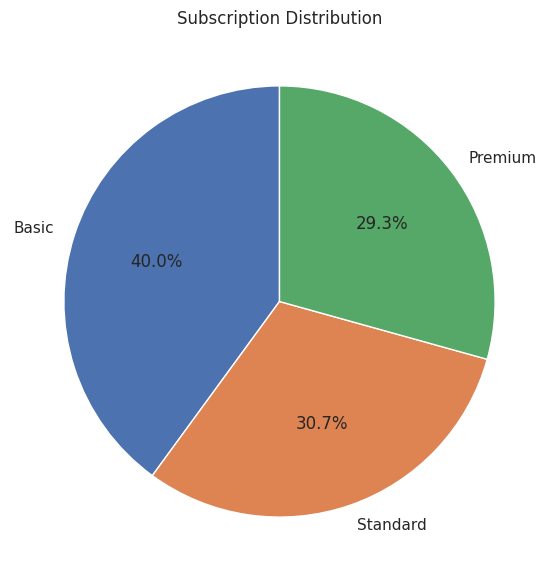

In [117]:
subscription_counts = Data['Subscription Type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    subscription_counts,
    labels=subscription_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Subscription Distribution')

plt.show()

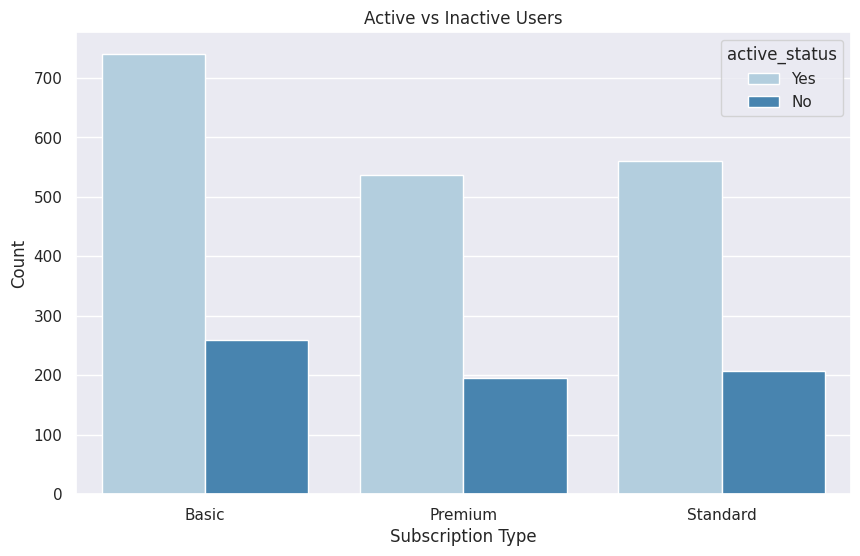

In [118]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Subscription Type',
    hue='active_status',
    data=Data,
    palette='Blues'
)

plt.title('Active vs Inactive Users')
plt.xlabel('Subscription Type')
plt.ylabel('Count')

plt.show()

In [86]:
avg_revenue = Data.groupby(
    'Subscription Type'
)['Monthly Revenue'].mean().reset_index()

avg_revenue

,Subscription Type,Monthly Revenue
0,Basic,12.481481
1,Premium,12.590723
2,Standard,12.464844


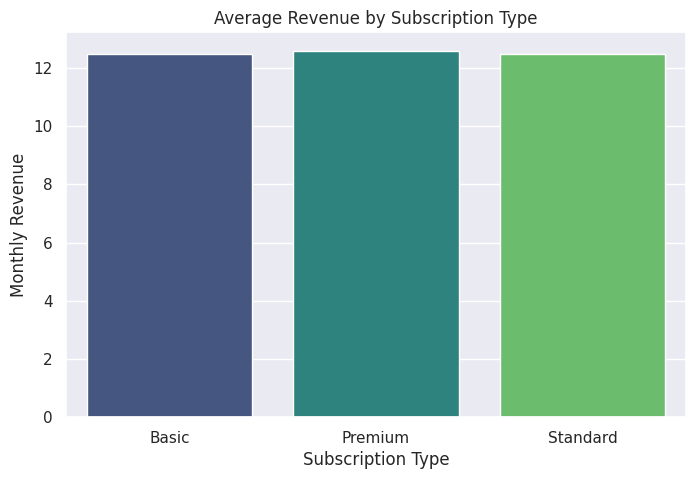

In [87]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Subscription Type',
    y='Monthly Revenue',
    data=avg_revenue,
    palette='viridis',
    hue='Subscription Type'
)

plt.title('Average Revenue by Subscription Type')

plt.show()

In [88]:
a = Data[Data['active_status']=='No'].groupby('Subscription Type').count()
a

,User ID,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,active_status
Subscription Type,,,,,,,,,,
Basic,259,259,259,259,259,259,259,259,259,259
Premium,196,196,196,196,196,196,196,196,196,196
Standard,208,208,208,208,208,208,208,208,208,208


In [89]:
Data['active_status'].value_counts()

,count
active_status,
Yes,1837
No,663


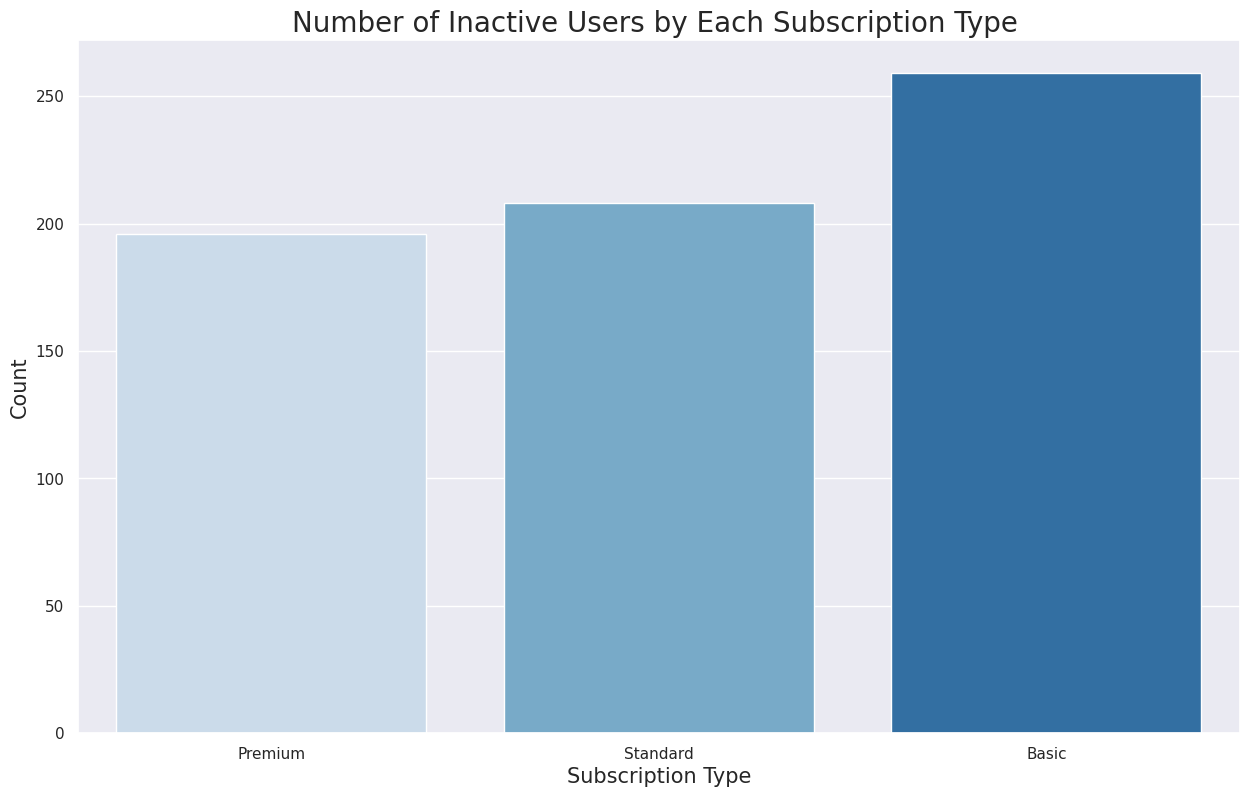

In [90]:
plt.figure(figsize = (15,9))
sns.countplot(x='Subscription Type', data = Data[Data['active_status']=='No'] ,palette = 'Blues', alpha=1)
plt.title('Number of Inactive Users by Each Subscription Type ',fontsize = 20)
plt.xlabel('Subscription Type',fontsize = 15)
plt.ylabel('Count',fontsize = 15)
plt.show()

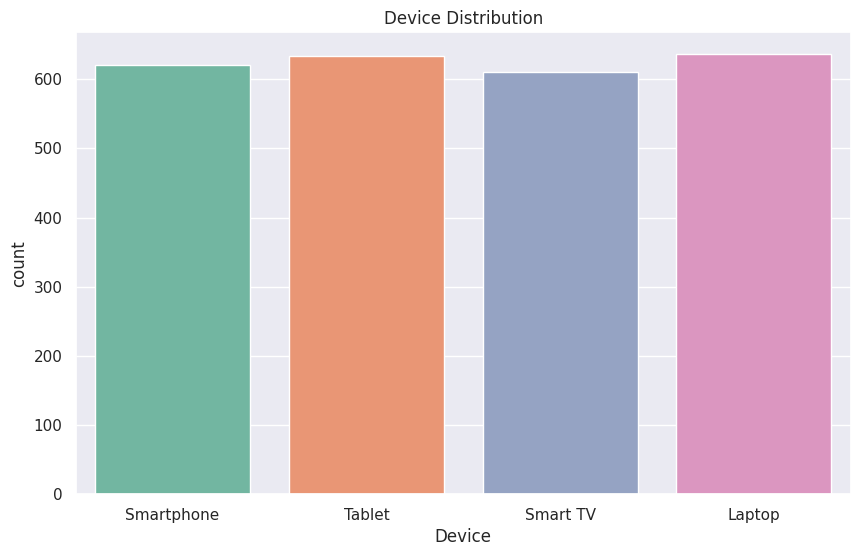

In [91]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='Device',
    data=Data,
    palette='Set2'
)

plt.title('Device Distribution')

plt.show()

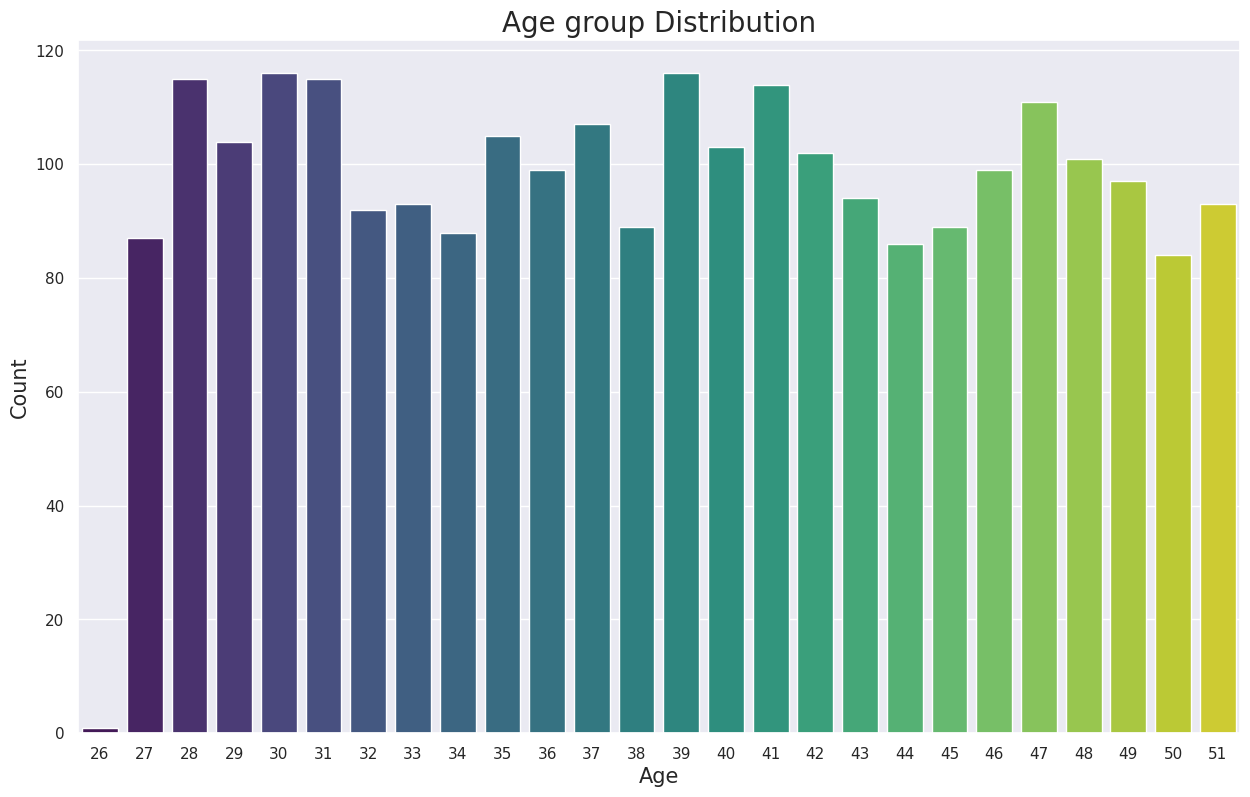

In [92]:
plt.figure(figsize = (15,9))
sns.countplot(x='Age', data = Data, palette='viridis', alpha=1)
plt.title('Age group Distribution',fontsize = 20)
plt.xlabel('Age',fontsize = 15)
plt.ylabel('Count',fontsize = 15)
plt.show()

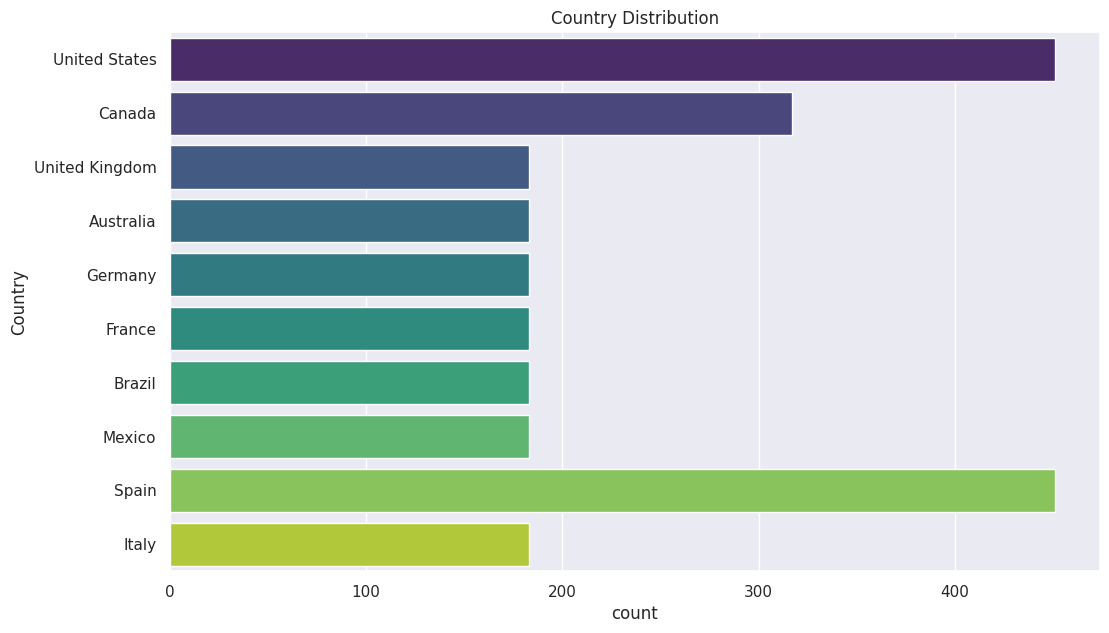

In [93]:
plt.figure(figsize=(12,7))

sns.countplot(
    y='Country',
    data=Data,
    palette='viridis'
)

plt.title('Country Distribution')

plt.show()

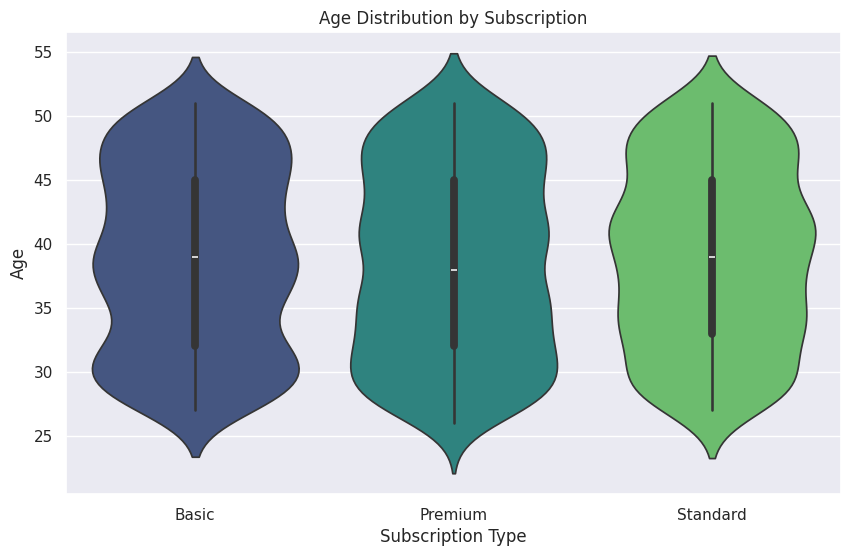

In [94]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='Subscription Type',
    y='Age',
    data=Data,
    palette='viridis',
    hue='Subscription Type'
)

plt.title('Age Distribution by Subscription')

plt.show()

In [95]:
corr = Data[['Monthly Revenue', 'Age']].corr()

corr

,Monthly Revenue,Age
Monthly Revenue,1.000000,-0.021143
Age,-0.021143,1.000000


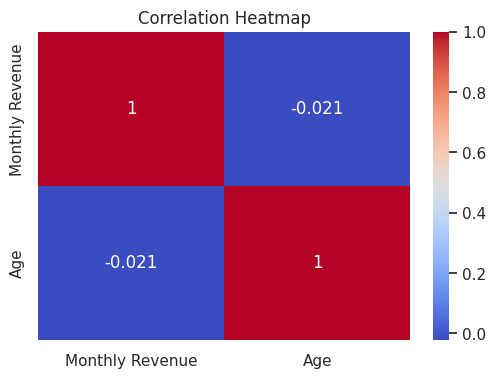

In [96]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [97]:
corr_coef, p_value = stats.pearsonr(
    Data['Age'],
    Data['Monthly Revenue']
)

print("Correlation Coefficient:", corr_coef)
print("P-value:", p_value)

Correlation Coefficient: -0.0211432640714474
P-value: 0.2906245022256895


In [98]:
male_revenue = Data[Data['Gender']=='Male']['Monthly Revenue']

female_revenue = Data[Data['Gender']=='Female']['Monthly Revenue']

t_stat, p_value = stats.ttest_ind(
    male_revenue,
    female_revenue
)

print("T-Statistic:", t_stat)
print("P-value:", p_value)

T-Statistic: -0.3068215064591685
P-value: 0.7590048104574644


In [99]:
contingency_table = pd.crosstab(
    Data['Gender'],
    Data['Subscription Type']
)

chi2, p, dof, expected = stats.chi2_contingency(
    contingency_table
)

print("Chi-Square Value:", chi2)
print("P-value:", p)

Chi-Square Value: 0.6282267388216123
P-value: 0.7304362143419852


In [100]:
print('STATISTICAL ANALYSIS RESULTS')

print('''
1. Pearson Correlation (Age vs Revenue):
   Coefficient : -0.021
   P-value     : 0.29
   Result      : P > 0.05 — NOT significant
   Meaning     : Age does NOT affect revenue
   Business    : Do not create age based
                 pricing strategy

2. T-Test (Male vs Female Revenue):
   T-Statistic : -0.306
   P-value     : 0.759
   Result      : P > 0.05 — NOT significant
   Meaning     : Male and Female spend equally
   Business    : Gender based offers will NOT
                 improve revenue

3. Chi-Square (Gender vs Subscription Type):
   Chi-Square  : 0.628
   P-value     : 0.730
   Result      : P > 0.05 — NOT significant
   Meaning     : Gender does NOT influence
                 subscription plan chosen
   Business    : Marketing should NOT be
                 gender targeted
''')

STATISTICAL ANALYSIS RESULTS

1. Pearson Correlation (Age vs Revenue):
   Coefficient : -0.021
   P-value     : 0.29
   Result      : P > 0.05 — NOT significant
   Meaning     : Age does NOT affect revenue
   Business    : Do not create age based 
                 pricing strategy

2. T-Test (Male vs Female Revenue):
   T-Statistic : -0.306
   P-value     : 0.759
   Result      : P > 0.05 — NOT significant
   Meaning     : Male and Female spend equally
   Business    : Gender based offers will NOT
                 improve revenue

3. Chi-Square (Gender vs Subscription Type):
   Chi-Square  : 0.628
   P-value     : 0.730
   Result      : P > 0.05 — NOT significant
   Meaning     : Gender does NOT influence 
                 subscription plan chosen
   Business    : Marketing should NOT be 
                 gender targeted



In [101]:
churn_count  = Data[Data['active_status']=='No'].shape[0]
active_count = Data[Data['active_status']=='Yes'].shape[0]
at_risk_rev  = Data[Data['active_status']=='No']['Monthly Revenue'].sum()

print('BUSINESS SUMMARY')

print(f'Total Users    : {len(Data)}')
print(f'Active Users   : {active_count} (73.48%)')
print(f'Inactive Users : {churn_count} (26.52%)')
print(f'Revenue at Risk: ${at_risk_rev:,} per month')
print()
print('Key Findings:')
print('  → Age and Gender do NOT drive revenue')
print('  → Basic plan has highest inactive users')
print('  → Revenue consistent across genders')
print()
print('Recommendations:')
print(f'  1. Target Basic plan users with upgrade offers')
print(f'  2. Run device specific campaigns')
print(f'  3. Protect Premium plan users — highest revenue')
print(f'  4. Win-back campaign for {churn_count} inactive users')
print(f'     to recover ${at_risk_rev:,} monthly revenue')

BUSINESS SUMMARY
Total Users    : 2500
Active Users   : 1837 (73.48%)
Inactive Users : 663 (26.52%)
Revenue at Risk: $8,295 per month

Key Findings:
  → Age and Gender do NOT drive revenue
  → Basic plan has highest inactive users
  → Revenue consistent across genders

Recommendations:
  1. Target Basic plan users with upgrade offers
  2. Run device specific campaigns
  3. Protect Premium plan users — highest revenue
  4. Win-back campaign for 663 inactive users
     to recover $8,295 monthly revenue
